# Book Genre Multi Label Text Classification (text-based)
### **Course and Year:** TU862/2, ML/AI stream
### **Module:** Project
### **Group Members:** 
##### **Student 1:** Kornel Zaleski X00222004 
##### **Student 2:** Lukasz Kiraga X00227628 
##### **Student 3:** Blessing Mayindu X00224444
##### Goal: The goal for this project is to predict book genres based on its title and summary.

In [ ]:
# !pip install numpy
# !pip install matplotlib
# !pip install scikit-learn
# !pip install scikit-multilearn
# !pip install pandas
# !pip install torch torchvision torchaudio
# !pip install tensorflow
# !pip install transformers
# !pip install pandas 
# !pip install tabulate


## 1. Importing Necessary Libraries

In [ ]:
# Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report, hamming_loss
import joblib
import pandas as pd
import tensorflow as tf
import torch

# https://pytorch.org/get-started/locally/
gpu_available = torch.cuda.is_available()
if gpu_available:
    print("CUDA Version:", torch.version.cuda)
    print("GPU Name:", torch.cuda.get_device_name(0))

import transformers
from transformers import BertTokenizer, BertModel, BertForSequenceClassification, BertConfig, Trainer, TrainingArguments
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns
import glob
import os


CUDA Version: 13.0
GPU Name: NVIDIA GeForce RTX 4060 Ti


c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.  Data Exploration

### Analysing data through the three datasets

BooksDataset.csv loaded successfully.

-----------Dataset Shape & Columns-----------

Shape:  (103082, 5)
Columns:  ['Title', 'Author', 'Description', 'Category', 'Publisher']

-----------Description of dataset columns-----------

                 Title  Author  \
count           103082  102990   
unique           97813   63579   
top     The Nutcracker      By   
freq                12    1043   

                                              Description  \
count                                               70213   
unique                                              68831   
top     For Ingest Only - Data needs to be cleaned up ...   
freq                                                   30   

                    Category         Publisher  
count                  76911            103074  
unique                  3106             13029  
top     "Fiction", "General"  Simon & Schuster  
freq                    2549              1521   


-----------Dataset Overall Info-----------



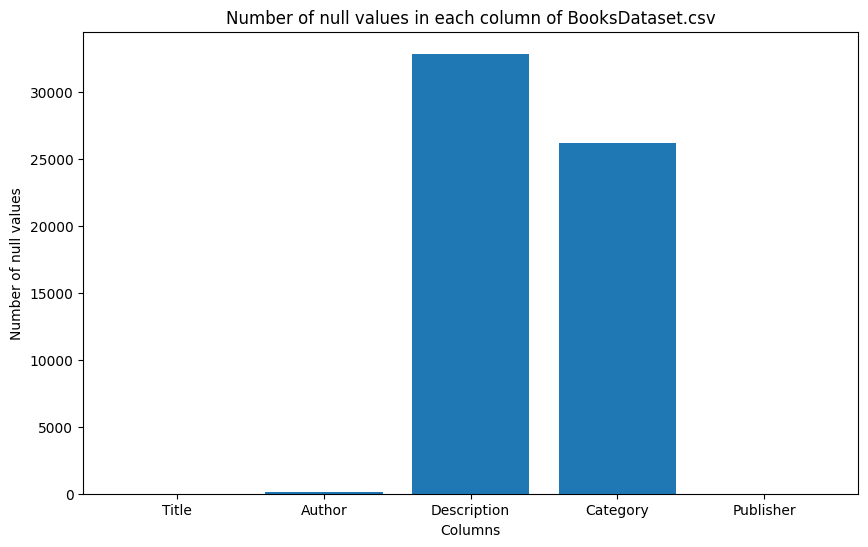

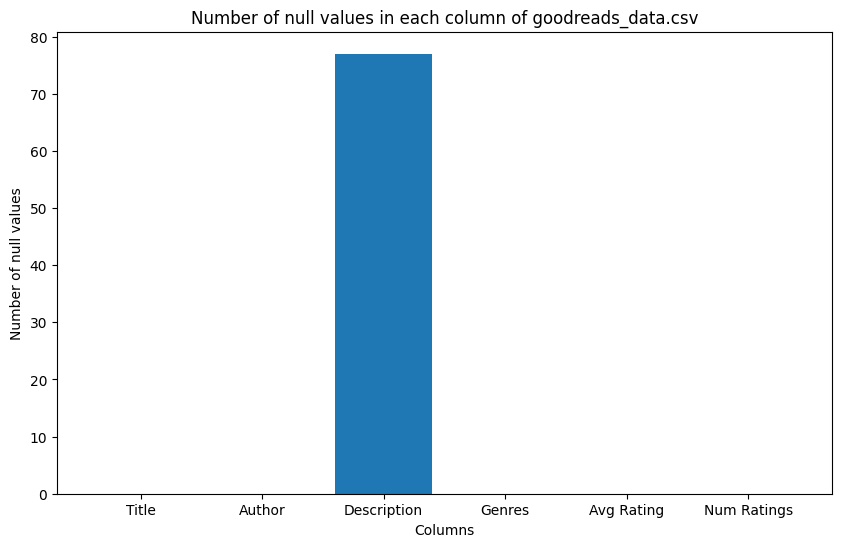

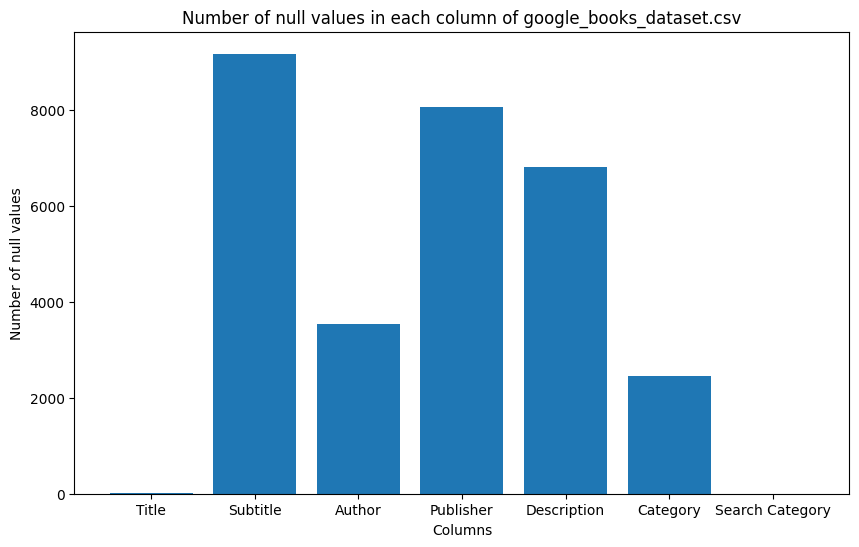

In [ ]:
# BooksDataset.csv - df1
df1 = pd.read_csv('BooksDataset.csv')
print("BooksDataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df1.shape)
print("Columns: ", df1.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df1.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df1.info(), "\n")
print("\n" + ("-"*30), "\n")

# goodreads_data.csv - df2
df2 = pd.read_csv('goodreads_data.csv')
print("goodreads_data.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df2.shape)
print("Columns: ", df2.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df2.describe(include='all'), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df2.info(), "\n")
print("\n" + ("-"*30), "\n")


# google_books_dataset.csv - df3
df3 = pd.read_csv('google_books_dataset.csv')
print("google_books_dataset.csv loaded successfully.")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df3.shape)
print("Columns: ", df3.columns.tolist())
print("\n-----------Description of dataset columns-----------\n")
print(df3.describe(), "\n")
print("\n-----------Dataset Overall Info-----------\n")
print(df3.info())
print("\n" + ("-"*30), "\n")

# Number of nulls in not cleaned datasets
print("\nNull values in each uncleaned dataset\n")
print("Number of null values in BooksDataset.csv")
nulls_df1og = df1.isnull().sum()
print(nulls_df1og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in goodreads_data.csv")
nulls_df2og = df2.isnull().sum()
print(nulls_df2og)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in google_books_dataset.csv")
nulls_df3og = df3.isnull().sum()
print(nulls_df3og)
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each not cleaned dataset for checking that cleaning worked as intended (checking if nan values are removed)
print("BooksDataset.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("goodreads_data.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("google_books_dataset.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

# Data visualization of null values in not cleaned datasets

# BooksDataset.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df1og.index, nulls_df1og.values)
plt.title("Number of null values in each column of BooksDataset.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# goodreads_data.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df2og.index, nulls_df2og.values)
plt.title("Number of null values in each column of goodreads_data.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# google_books_dataset.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df3og.index, nulls_df3og.values)
plt.title("Number of null values in each column of google_books_dataset.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

## 3. Data Cleaning
### Each dataset will be cleaned before merging


Null values in each cleaned dataset

Number of null values in BooksDatasetClean.csv
Title           0
Author         11
Description     0
Category        0
Publisher       0
dtype: int64

------------------------------ 


Number of null values in GoodreadsDatasetClean.csv
Title          0
Author         0
Description    0
Genres         0
Avg Rating     0
Num Ratings    0
dtype: int64

------------------------------ 


Number of null values in GoogleBooksDatasetClean.csv
Title                 0
Subtitle           3565
Author              299
Publisher          1135
Description           0
Category              0
Search Category       0
dtype: int64

------------------------------ 


Null values comparison (uncleaned vs cleaned)

BooksDataset.csv vs BooksDatasetClean.csv
              Uncleaned  Cleaned
Title                0        0
Author              92       11
Description      32869        0
Category         26171        0
Publisher            8        0 


----------------------

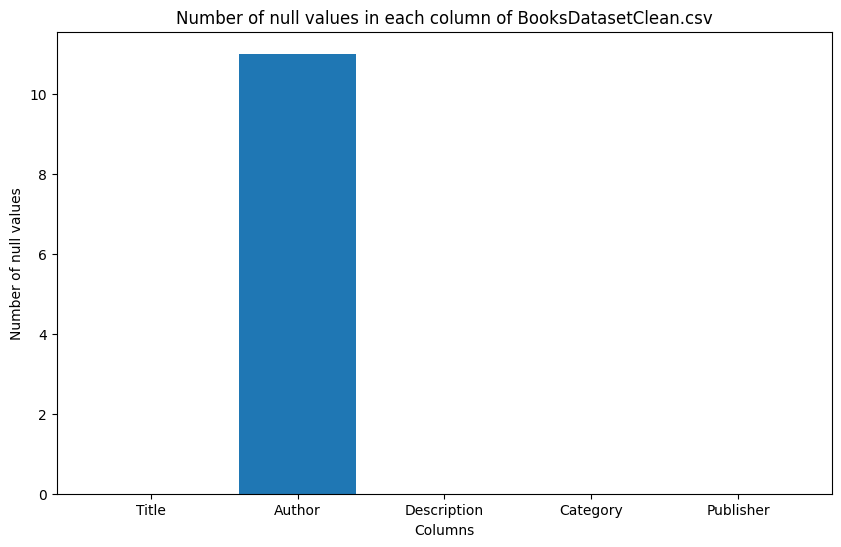

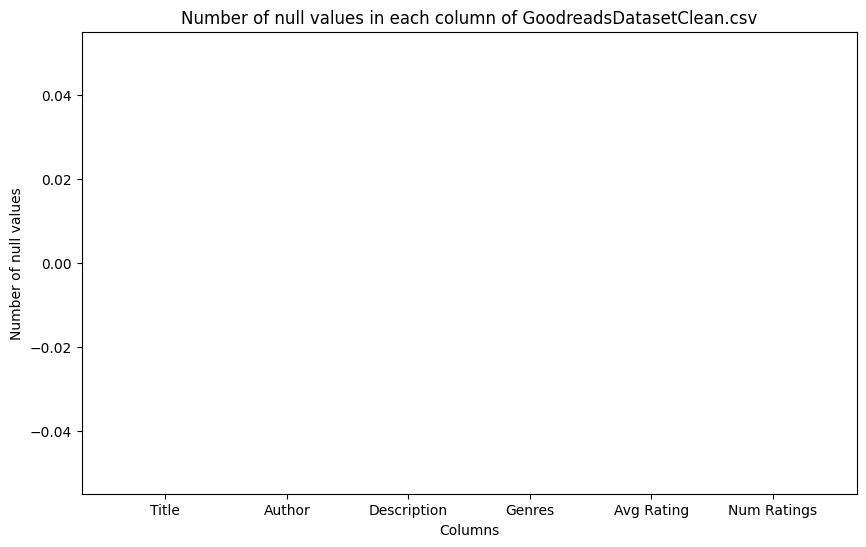

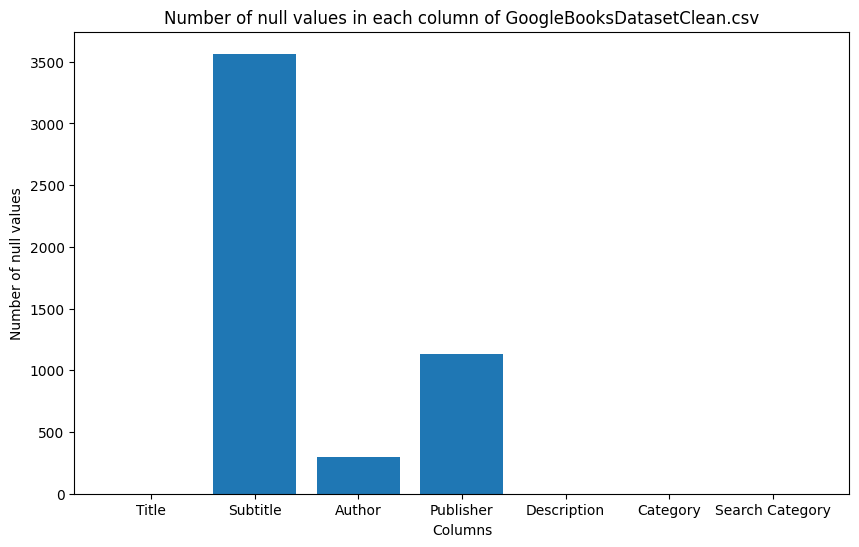

In [3]:
# Load and save the cleaned datasets

# BooksDataset.csv - df1
df1 = df1.dropna(subset=['Title', 'Description', 'Category'], how='any')
df1 = df1.drop_duplicates()
#df1.to_csv('BooksDatasetClean.csv', encoding="utf-8", index=False)

# goodreads_data.csv - df2
df2 = df2.dropna(subset=['Title', 'Description', 'Genres'], how='any')
df2 = df2.drop_duplicates()
#df2.to_csv('GoodreadsDatasetClean.csv', encoding="utf-8", index=False)

# google_books_dataset.csv - df3
df3 = df3.dropna(subset=['Title', 'Description', 'Category'], how='any')
df3 = df3.drop_duplicates()
#df3.to_csv('GoogleBooksDatasetClean.csv', encoding="utf-8", index=False)

# Number of nulls in cleaned datasets
print("\nNull values in each cleaned dataset\n")
print("Number of null values in BooksDatasetClean.csv")
nulls_df1 = df1.isnull().sum()
print(nulls_df1)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoodreadsDatasetClean.csv")
nulls_df2 = df2.isnull().sum()
print(nulls_df2)
print("\n" + ("-"*30), "\n")
print("\nNumber of null values in GoogleBooksDatasetClean.csv")
nulls_df3 = df3.isnull().sum()
print(nulls_df3)
print("\n" + ("-"*30), "\n")

# Nulls in each uncleaned and cleaned datasets comparison
print("\nNull values comparison (uncleaned vs cleaned)\n")
print("BooksDataset.csv vs BooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df1og, 'Cleaned': nulls_df1}), "\n")
print("\n" + ("-"*30), "\n")
print("goodreads_data.csv vs GoodreadsDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df2og, 'Cleaned': nulls_df2}), "\n")
print("\n" + ("-"*30), "\n")
print("google_books_dataset.csv vs GoogleBooksDatasetClean.csv\n", pd.DataFrame({'Uncleaned': nulls_df3og, 'Cleaned': nulls_df3}), "\n")
print("\n" + ("-"*30), "\n")

# Display the first 15 rows of each cleaned dataset to ensure the cleaning process
print("BooksDatasetClean.csv\n\n", df1.head(15).to_markdown(index=False), "\n")
print("GoodreadsDatasetClean.csv\n\n", df2.head(15).to_markdown(index=False), "\n")
print("GoogleBooksDatasetClean.csv\n\n", df3.head(15).to_markdown(index=False), "\n")

# Data visualization of null values in not cleaned datasets

# BooksDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df1.index, nulls_df1.values)
plt.title("Number of null values in each column of BooksDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# GoodreadsDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df2.index, nulls_df2.values)
plt.title("Number of null values in each column of GoodreadsDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

# GoogleBooksDatasetClean.csv
plt.figure(figsize=(10, 6))
plt.bar(nulls_df3.index, nulls_df3.values)
plt.title("Number of null values in each column of GoogleBooksDatasetClean.csv")
plt.xlabel("Columns")
plt.ylabel("Number of null values")
plt.show()

## 4. Data merging


In [4]:

# Merging two csv files

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

final_df = pd.concat(
    [df1[common_columns], df2[common_columns], df3[common_columns]],
    ignore_index=True
)

print(final_df.head())
# Here I am showing that the columns have difference headers . To fix this I need to make them the same and then put them together.
print("DF1 columns:")
print(df1.columns.tolist())

print("\nDF2 columns:")
print(df2.columns.tolist())

print("\nDF3 columns:")
print(df3.columns.tolist())

# Making all the columns lowercase
for df in [df1, df2, df3]:
    df.columns = df.columns.str.lower().str.strip()

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)
print(common_columns)

                                               Title  \
0                         Journey Through Heartsongs   
1                       In Search of Melancholy Baby   
2       The Dieter's Guide to Weight Loss During Sex   
3  Germs : Biological Weapons and America's Secre...   
4  The Good Book: Reading the Bible with Mind and...   

                                              Author  \
0                             Stepanek, Mattie J. T.   
1  Aksyonov, Vassily, Heim, Michael Henry, and Bo...   
2                                     Smith, Richard   
3  Miller, Judith, Engelberg, Stephen, and Broad,...   
4                                    Gomes, Peter J.   

                                         Description  
0  Collects poems written the eleven-year-old mus...  
1  The Russian author offers an affectionate chro...  
2  A humor classic, this tongue-in-cheek diet pla...  
3  Deadly germs sprayed in shopping malls, bomb-l...  
4  "The Bible and the social and moral consequenc..


Common columns: Index(['title', 'description'], dtype='str')
Number of null values in each column in the merged dataset:
title                  0
authors             7403
description            0
categories          7392
publisher          11039
avg rating         72618
num ratings        72618
subtitle           78695
author             75429
category           75130
search category    75130
dtype: int64

Final merged dataset:

-----------Dataset Shape & Columns-----------

Shape:  (82522, 11)
Columns:  ['title', 'authors', 'description', 'categories', 'publisher', 'avg rating', 'num ratings', 'subtitle', 'author', 'category', 'search category']

-----------Dataset First and Last 15 rows-----------

First 15 rows

 | title                                                                  | authors                                                                 | description                                                                                                                 

Text(0, 0.5, 'Number of null values')

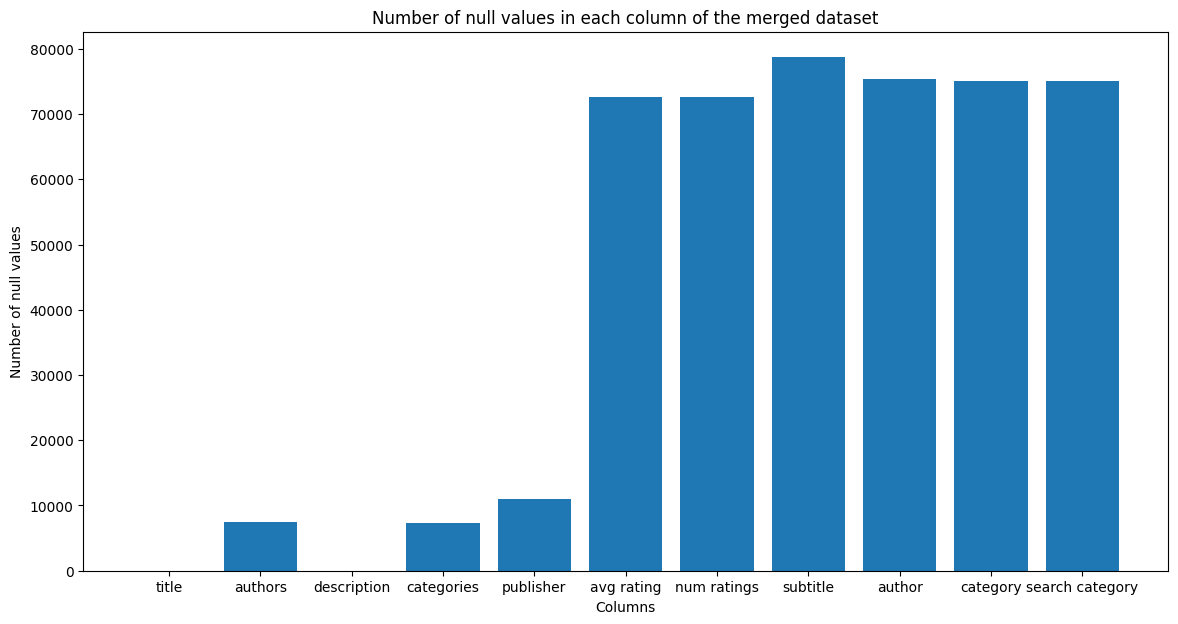

In [5]:
#Here I am matching header names to the df3 
#pandas.DataFrame.rename

dfs = []
for df_loop in [df1, df2, df3]:
    df_loop.columns = df_loop.columns.str.lower().str.strip()
    dfs.append(df_loop)

df1,df2,df3 = dfs

df2 = df2.rename(columns={
    "book": "title",
    "author": "authors",
    "genres": "categories"
})

df1 = df1.rename(columns={
    "category": "categories",
    "author": "authors"
})
#df1 = df1.rename(columns={"categories": "category"})
#df2 = df2.rename(columns={"categories": "category"})
#df3 = df3.rename(columns={"categories": "category"})

common_columns = df1.columns.intersection(df2.columns).intersection(df3.columns)

print("\nCommon columns:", common_columns)
# Merge
df = pd.concat([df1, df2, df3], ignore_index=True)
df.to_csv('MergedBooksDataset.csv', encoding="utf-8", index=False)

print("Number of null values in each column in the merged dataset:\n" + str(df.isnull().sum()))

print("\nFinal merged dataset:")
print("\n-----------Dataset Shape & Columns-----------\n")
print("Shape: ", df.shape)
print("Columns: ", df.columns.tolist())
print("\n-----------Dataset First and Last 15 rows-----------\n")
print("First 15 rows\n\n", df.head(15).to_markdown(index=False), "\n")
print("Last 15 rows\n\n", df.tail(15).to_markdown(index=False), "\n")
print("\n-----------Description of dataset columns-----------\n")
print(df.describe(), "\n")
print("\n" + ("-"*30), "\n")
print("\nNumber of categories: ")
print(df["category"].value_counts().head(20))
print("\n-----------Dataset Overall Info-----------\n")
print(df.info())
print("Number of genres:", df["category"].value_counts().sum())

# Data visualization of null values in the merged dataset
plt.figure(figsize=(14, 7))
plt.bar(df.isnull().sum().index, df.isnull().sum().values)
plt.title("Number of null values in each column of the merged dataset")
plt.xlabel("Columns")
plt.ylabel("Number of null values")

### Data Visualisation - Categories

##### Using a bar and pie charts from matplotlib, it will show the top 10 categories that are most frequently occurring in the merged dataset

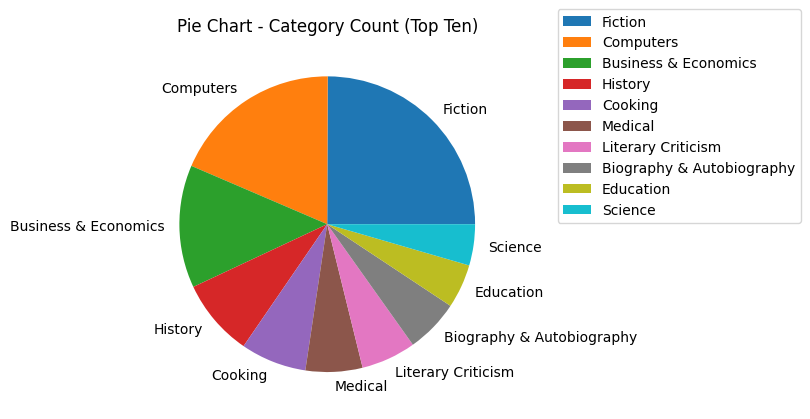

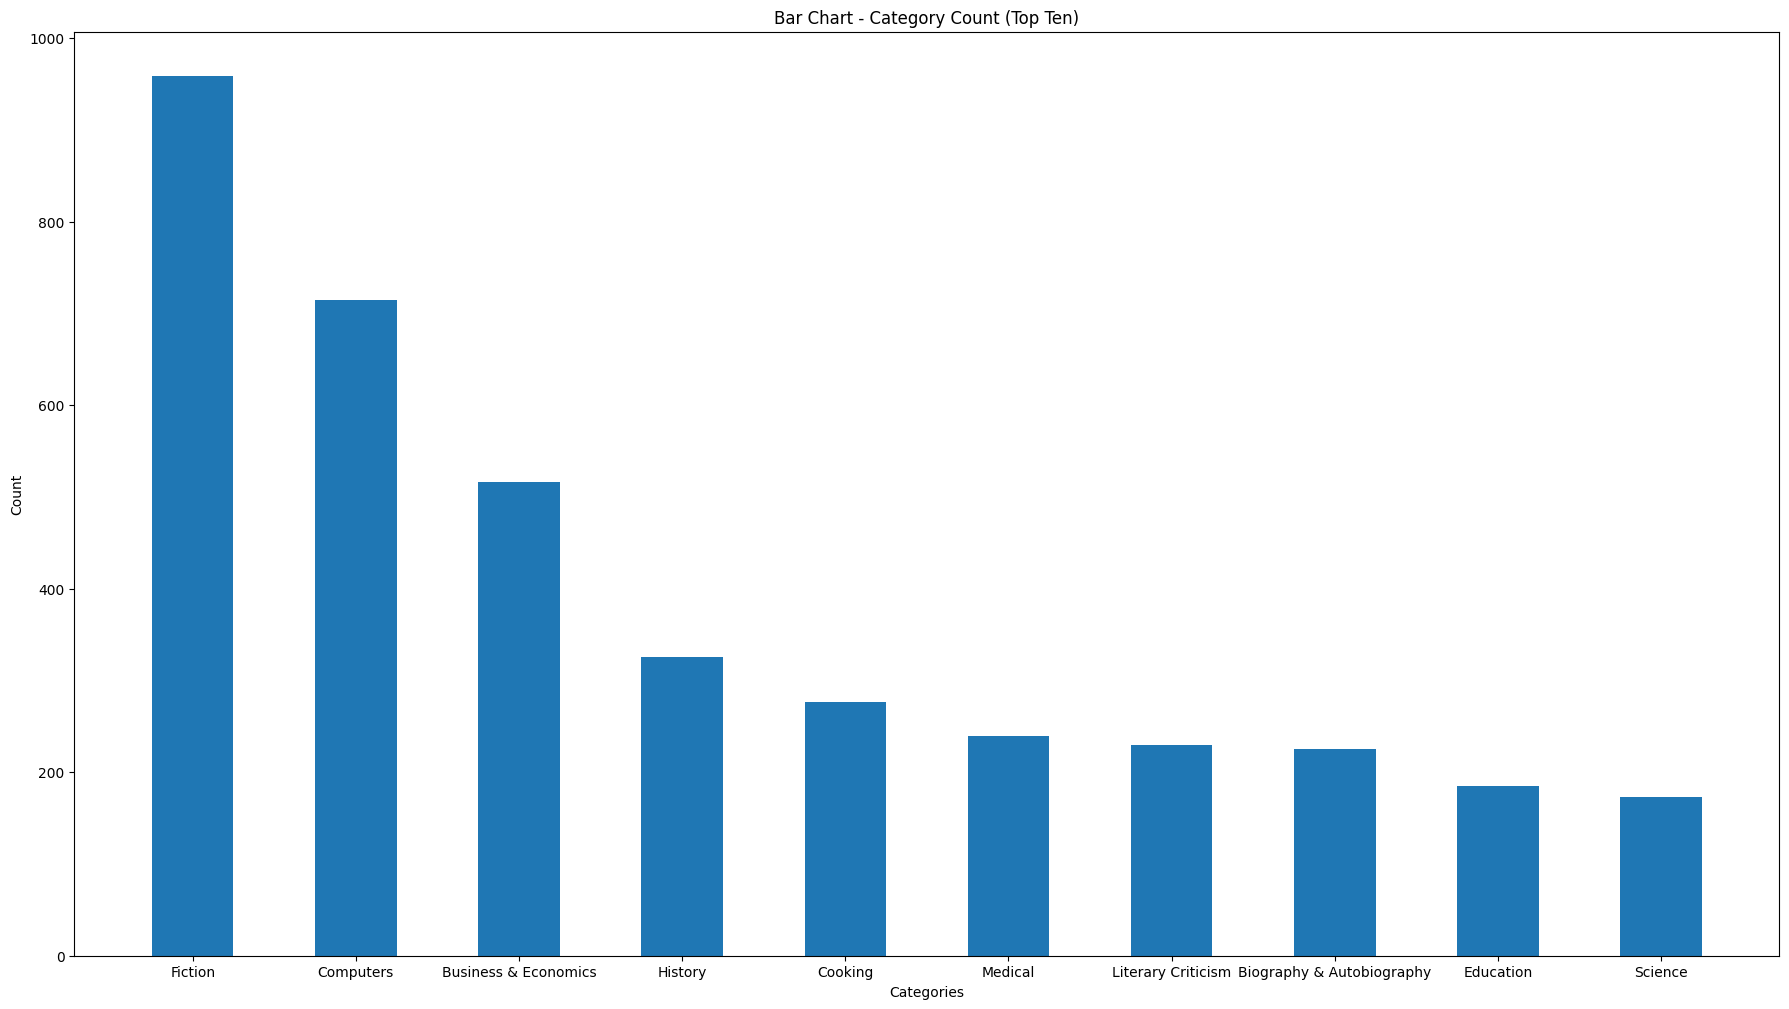

In [6]:
categories = df["category"].value_counts().head(10).index.tolist()
count = df["category"].value_counts().head(10).values.tolist()
new_categories = []

for category in categories:
    category = category.replace('"', '')
    new_categories.append(category)
    
categories = new_categories

plt.pie(count, labels=categories)
plt.title("Pie Chart - Category Count (Top Ten)")
plt.legend(categories, loc="upper right", bbox_to_anchor=(1.7, 1, 0.1, 0.1))
plt.show()

plt.figure(figsize=(22, 12))
plt.bar(categories, count, width=0.5)
plt.title("Bar Chart - Category Count (Top Ten)")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.show()

## 5. Feature Selection

In [7]:
#tfidf = TfidfVectorizer()
mlb = MultiLabelBinarizer()
#result = tfidf.fit_transform(df)
#print('\nidf values:') 
#for ele1, ele2 in zip(tfidf.get_feature_names_out(),
#tfidf.idf_): print(ele1, ':', ele2) 
#print('\nWord indexes:') 
#print(tfidf.vocabulary_)
#print('\ntf-idf value:') 
#print(result) 
#print('\ntf-idf values in matrix form:') 
#print(result.toarray())
#the max feature will keep the 5000 most usefull words.
df = df.dropna(subset=['categories'], how='any')
tfidf = TfidfVectorizer(max_features=5000 ,stop_words='english')
# the stop word will remove useless word like 'a','is' etc -They are jsut filler words.
texts = (df['title'] + " " + df['description'])
X = texts
print(df['categories'].head(10))
categories_list = df['categories'].apply(lambda x: [category.strip().replace('"', '') for category in str(x).split(',')] if pd.notna(x) else []).tolist()
#categories_list = df['categories'].apply(lambda x: [x] if isinstance(x, str) else x)
y = mlb.fit_transform(categories_list)

print("Sample of the multi-label binarized output (first 5 rows):\n", y[:5])
print("feature matrix shape:", X.shape)
print("Number of genres:",len(mlb.classes_))
print("genre:", mlb.classes_)
print(type(mlb.classes_))

0                                "Poetry", "General"
1             "Biography & Autobiography", "General"
2    "Health & Fitness", "Diet & Nutrition", "Diets"
3     "Technology & Engineering", "Military Science"
4        "Religion", "Biblical Biography", "General"
5    "Biography & Autobiography", "Personal Memoirs"
6                     "Political Science", "General"
7                          "Pets", "Cats", "General"
8                     "Political Science", "General"
9                               "Fiction", "General"
Name: categories, dtype: str
Sample of the multi-label binarized output (first 5 rows):
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
feature matrix shape: (75130,)
Number of genres: 2423
genre: ['12th Century' '15th Century' '16th Century' ... 'etc.' 'etc.)'
 'the Gospels & Acts']
<class 'numpy.ndarray'>


## 6. Dataset Splits

#### We split the dataset into three sets:
 - **Training set**: fitting the models (70%)
 - **Validation set**: tuning and comparison (15%)
 - **Test set**: final unbiased evaluation (15%)

In [ ]:
# Splitting the dataset into training, validation, and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Checking the shapes of the training, validation, and test sets
print("Training set shape: ", X_train.shape)
print("Validation set shape: ", X_val.shape)
print("Test set shape: ", X_test.shape)

# Checking the first 5 rows of training genres and the number of genres
print(mlb.inverse_transform(y_train[:5]))
print(len(mlb.classes_))

Training set shape:  (52591,)
Validation set shape:  (11269,)
Test set shape:  (11270,)
[('Fiction', 'General', 'Mystery & Detective'), ('Business & Economics', 'General', 'Investments & Securities'), ('American', 'Cooking', 'Regional & Ethnic', 'Southern States'), ('Juvenile Fiction', 'Media Tie-In'), ('Boating', 'Sports & Recreation')]
2423
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


## TF-IDF Vectorizer
#### We covert training, validation and test set texts into TF-IDF vectors so the ML models work 

In [9]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

## Machine Learning Models
### 1. Logistic Regression

In [ ]:
# Initialise the Logistic Regression model with the maximum number of iterations as the parameter and the solver set as 'liblinear'
# We use OneVsRestClassifier wrapper for multi-label classification
log_reg = OneVsRestClassifier(LogisticRegression(max_iter=100, solver='liblinear'))

# Fit the Logistic Regression model on the training data
log_reg.fit(X_train_tfidf, y_train)

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warni

Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       A+       0.00     

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

### 2. Naive Bayes

In [ ]:
# Initialise the Naive Bayes model with the OneVsRestClassifier wrapper for multi-label classification
naive_bayes = OneVsRestClassifier(MultinomialNB())

# Fit the Naive Bayes model on the training data
naive_bayes.fit(X_train_tfidf, y_train)

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 14 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 29 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 63 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 67 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 102 is present in all training examples.
  warnings.warn(
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\multiclass.py:90: UserWarning: Label not 103 is present in all training examples.
  warni

Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                       A+       0.00     

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

## Deep Learning Model

### 3. BERT (Bidirectional Encoder Representations from Transformers)
##### We now do the BERT tokenizer so we firstly take the tokenizer from huggingface, then we initialise the tokenizer for the two sets with the function and then tokenize them.

In [12]:
# BERT Tokenizer
# Initialising the tokenizer from the hugging face transformers library for the BERT model.
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

# Function to tokenize the data using the tokenizer
def tokenize_data(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors='pt')

# Tokenizing the training, validation, and test data using the tokenize_data function
X_train_tokenize = tokenize_data(X_train)
X_valid_tokenize = tokenize_data(X_val)


### BERT - Model Preparation and Fitting

In [ ]:
# X_train_tokens = tokenizer.convert_ids_to_tokens(X_train_tokenize['input_ids'][0])
# print(X_train_tokens)
# X_valid_tokens = tokenizer.convert_ids_to_tokens(X_valid_tokenize['input_ids'][0])
# print(X_valid_tokens)

# Checks if NVIDIA GPU is available otherwise defaults to CPU
device = torch.device('cuda' if gpu_available else 'cpu')

# Custom dataset class for multi-label classification to prepare BERT
class MultiLabelBookGenreDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item
    
# Creating datasets for training and validation using the class above with the encodings and label splits
train_dataset = MultiLabelBookGenreDataset(X_train_tokenize, y_train)
valid_dataset = MultiLabelBookGenreDataset(X_valid_tokenize, y_val)

# Initialise BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(mlb.classes_),
    problem_type='multi_label_classification'
)

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
# criterion = torch.nn.BCEWithLogitsLoss()

# If NVIDIA GPU is available it moves the model to the GPU otherwise it moves to CPU
model.to(device)
print("BERT successfully set up")
if device == torch.device('cuda'):
    print("Moved to device NVIDIA GPU CUDA -", torch.cuda.get_device_name(0))
else:
    print("Moved to device CPU by default")


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERT successfully set up
Moved to device NVIDIA GPU CUDA - NVIDIA GeForce RTX 4060 Ti


### Training BERT
##### To train BERT, we firstly set the training arguments then we set up the trainer using training and valid sets to train it

In [17]:
# Setting up the training arguments for the Trainer class from transformers
train_arguments = TrainingArguments(
    output_dir='./BERTresults',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    fp16=gpu_available,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_dir='./logs'
)

# Create the trainer to train BERT
trainer = Trainer(model=model, args=train_arguments, train_dataset=train_dataset, eval_dataset=valid_dataset)

In [18]:
# Starts training BERT
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.006600,0.006522
2,0.006400,0.006421
3,0.006300,0.006202


TrainOutput(global_step=9861, training_loss=0.01022586814289269, metrics={'train_runtime': 2687.3534, 'train_samples_per_second': 58.709, 'train_steps_per_second': 3.669, 'total_flos': 4.241417054044262e+16, 'train_loss': 0.01022586814289269, 'epoch': 3.0})

## Save Models

In [19]:
# Make saved_models directory (folder) if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

# Save TF-IDF Vectorizer
try:
    if 'tfidf' in locals() or 'tfidf' in globals():
        joblib.dump(tfidf, 'saved_models/tfidf_vectorizer.joblib')
        print("TF-IDF Vectorizer saved successfully.")
    else:
        print("Error - TF-IDF Vectorizer not found, unable to save.")
except Exception as e:
    print("Error - Could not save TF-IDF Vectorizer. Result: " + str(e) + ".")


# Save Logistic Regression model
try:
    if 'log_reg' in locals() or 'log_reg' in globals():
        joblib.dump(log_reg, 'saved_models/logistic_regression_model.joblib')
        print("Logistic Regression model saved successfully.")
    else:
        print("Error - Logistic Regression model not found, unable to save.")
except Exception as e:
    print("Error - Could not save Logistic Regression model. Result: " + str(e) + ".")

# Save Naive Bayes model
try:
    if 'naive_bayes' in locals() or 'naive_bayes' in globals():
        joblib.dump(naive_bayes, 'saved_models/naive_bayes_model.joblib')
        print("Naive Bayes model saved successfully.")
    else:
        print("Error - Naive Bayes model not found, unable to save.")
except Exception as e:
    print("Error - Could not save Naive Bayes model. Result: " + str(e) + ".")


# Save BERT model and tokenizer
try:
    if ('trainer' in locals() or 'trainer' in globals()) and ('tokenizer' in locals() or 'tokenizer' in globals()):
        trainer.save_model('saved_models/bert_model')
        tokenizer.save_pretrained('saved_models/bert_model')
        print("BERT model and tokenizer saved successfully.")
    else:
        print("Error - BERT model and/or Tokenizer not found, unable to save.")
except Exception as e:
        print("Error - Could not save BERT and Tokenizer. Result: " + str(e) + ".")

TF-IDF Vectorizer saved successfully.
Logistic Regression model saved successfully.
Naive Bayes model saved successfully.
BERT model and tokenizer saved successfully.


## Load Models

In [ ]:
# Load TF-IDF Vectorizer
try:
    if os.path.exists('saved_models/tfidf_vectorizer.joblib'):
        tfidf_loaded = joblib.load('saved_models/tfidf_vectorizer.joblib')
        print("TF-IDF Vectorizer loaded successfully.")
    else:
        print("Error - TF-IDF Vectorizer file not found, unable to load.")
except Exception as e:
    print("Error - Could not load TF-IDF Vectorizer. Result: " + str(e) + ".")

# Load Logistic Regression model
try:
    if os.path.exists('saved_models/logistic_regression_model.joblib'):
        log_reg_loaded = joblib.load('saved_models/logistic_regression_model.joblib')
        print("Logistic Regression model loaded successfully.")
    else:
        print("Error - Logistic Regression model file not found, unable to load.")
except Exception as e:
    print("Error - Could not load Logistic Regression model. Result: " + str(e) + ".")

# Load Naive Bayes model
try:
    if os.path.exists('saved_models/naive_bayes_model.joblib'):
        naive_bayes_loaded = joblib.load('saved_models/naive_bayes_model.joblib')
        print("Naive Bayes model loaded successfully.")
    else:
        print("Error - Naive Bayes model file not found, unable to load.")
except Exception as e:
    print("Error - Could not load Naive Bayes model. Result: " + str(e) + ".")

# Load BERT model and tokenizer
try:
    if os.path.exists('saved_models/bert_model'):
        bert_loaded = BertForSequenceClassification.from_pretrained('saved_models/bert_model')
        bert_loaded.to(device)
        tokenizer_loaded = BertTokenizer.from_pretrained('saved_models/bert_model')
        print("BERT model and tokenizer loaded successfully.")
    else:
        print("Error - BERT model and/or tokenizer files not found, unable to load.")
except Exception as e:
    print("Error - Could not load BERT model and tokenizer. Result: " + str(e) + ".")


# Example of using the loaded models to make predictions on new data
# sample_books = ["Diary of a Wimpy Kid: Fight or Flight - When the going gets tough, what's a wimpy kid to do? In Fight or Flight, Greg Heffley faces his biggest challenge yet as he becomes a target for the school bully. Luckily for Greg, his best friend, Rowley Jefferson, takes karate, so at least Greg's got someone in his corner. But an unexpected twist makes Greg realize he's facing an uphill battle. Will Greg step into the ring or throw in the towel? One thing's for sure - Fight or Flight is a knockout!",
#                 "How to Achieve Financial Freedom: A Comprehensive Guide to Building Wealth and Securing Your Future - This comprehensive guide provides practical strategies and insights to help you achieve financial freedom. From budgeting and saving to investing and retirement planning, this book covers all aspects of personal finance. Whether you're just starting your financial journey or looking to take your wealth-building efforts to the next level, this book offers valuable advice and actionable steps to help you secure your financial future.",
#                 "The wonderful wizard of oz - The Wonderful Wizard of Oz is a children's novel written by L. Frank Baum and illustrated by W. W. Denslow. It was first published in 1900 and has since become one of the most famous and enduring works of American children's literature. The story follows a young girl named Dorothy who is swept away from her Kansas home to the magical land of Oz. Along with her dog Toto, Dorothy embarks on a journey to find the Wizard of Oz, who she believes can help her return home. Along the way, she meets memorable characters such as the Scarecrow, the Tin Woodman, and the Cowardly Lion, who join her on her quest. The novel explores themes of friendship, courage, and self-discovery, and has been adapted into numerous films, stage productions, and other media over the years. The Wonderful Wizard of Oz continues to captivate readers of all ages with its imaginative storytelling and timeless messages.",
#                 "Boeing 737 MAX: The Inside Story of the World's Deadliest Plane Crash - This book provides an in-depth look at the Boeing 737 MAX, the aircraft involved in two tragic crashes that resulted in the loss of hundreds of lives. It explores the design and development of the plane, the corporate culture at Boeing, and the regulatory failures that contributed to the disasters. Through extensive research and interviews with key players, this book sheds light on the factors that led to the crashes and the ongoing efforts to ensure aviation safety in the future.",
#                 "The Italian Foodscape: A Culinary Journey Through Italy's Regions - This book takes readers on a culinary journey through Italy's diverse regions, exploring the rich tapestry of flavors and traditions that define Italian cuisine. From the hearty dishes of the north to the vibrant flavors of the south, this book delves into the history, culture, and ingredients that make Italian food so beloved around the world. With recipes, anecdotes, and stunning photography, The Italian Foodscape celebrates the art of Italian cooking and invites readers to experience the magic of Italy's culinary heritage."]

# Transforming new texts using the loaded TF-IDF Vectorizer
# try:
#     if 'tfidf_loaded' in locals():
#         books_tfidf = tfidf_loaded.transform(sample_books)
#         print("TF-IDF transformation of the samples successful.")
#         print("TF-IDF feature matrix shape for sample books:", books_tfidf.shape)
#     else:
#         print("Error - Loaded TF-IDF Vectorizer not found, unable to transform new texts.")
# except Exception as e:
#     print("Error - Could not transform new texts with loaded TF-IDF Vectorizer. Result: " + str(e) + ".")


TF-IDF Vectorizer loaded successfully.
Logistic Regression model loaded successfully.
Naive Bayes model loaded successfully.
BERT model and tokenizer loaded successfully.
TF-IDF transformation of the samples successful.
TF-IDF feature matrix shape for sample books: (5, 5000)


## Predictions | Classification Reports | Data Visualisation
### Making predictions, producing classification reports, and a horizontal bar chart to display top 20 genres based on the F1 scores.

### Logistic Regression

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

Logistic Regression - Predictions and predicted probabilities
Logistic Regression predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Logistic Regression predicted probabilities:
 [[0.00017788 0.00018041 0.00040962 ... 0.001116   0.00032912 0.00017576]
 [0.00017203 0.00017682 0.00025049 ... 0.0011397  0.00035322 0.00017248]
 [0.00017476 0.00017388 0.00024783 ... 0.00325579 0.00036272 0.00017637]
 ...
 [0.00017782 0.00018221 0.00024982 ... 0.00128777 0.00033271 0.00017312]
 [0.00018439 0.00018314 0.00026137 ... 0.00140894 0.00035331 0.00018387]
 [0.00018713 0.00018619 0.0002769  ... 0.00560709 0.00048249 0.00018704]] 

Logistic Regression - Classification Reports
Validation Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
           

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elekt\AppData\Local\Temp\ipykernel_13972\514657987.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


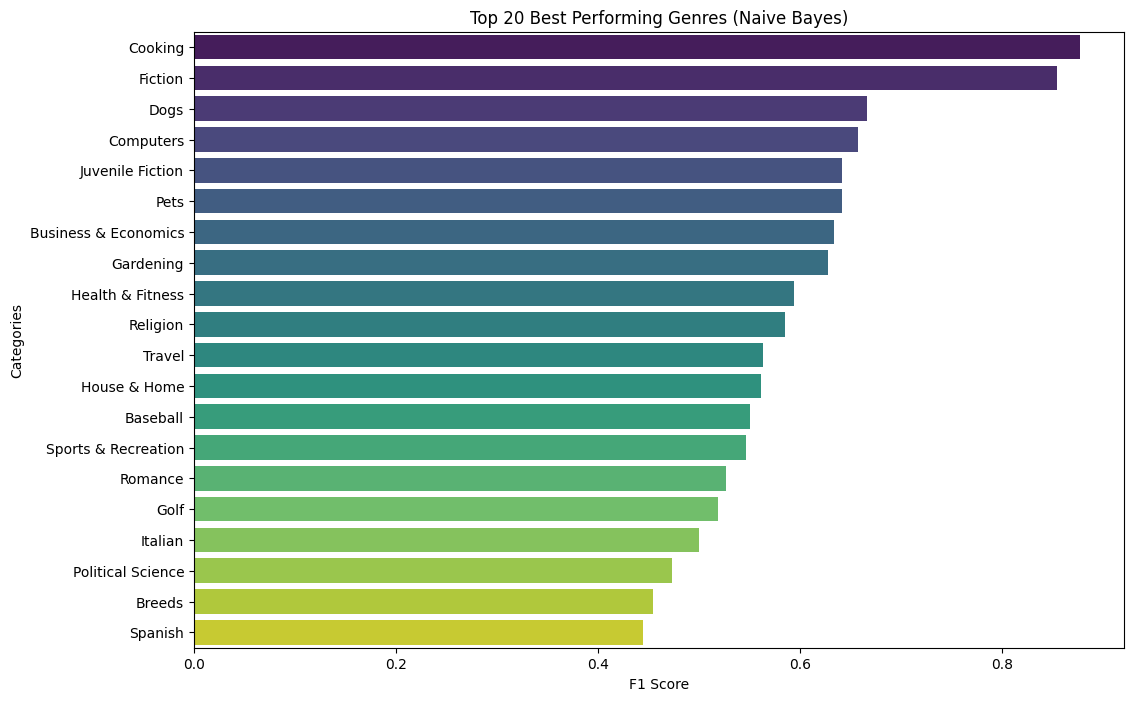

In [ ]:
# Logistic Regression
try:
    if 'tfidf_loaded' in locals() and 'log_reg_loaded' in locals():
        # Make predictions and predicted probabilities for validation and test sets
        y_val_lr_pred = log_reg_loaded.predict(X_val_tfidf)
        y_test_lr_pred = log_reg_loaded.predict(X_test_tfidf)
        y_val_lr_proba = log_reg_loaded.predict_proba(X_val_tfidf)
        y_test_lr_proba = log_reg_loaded.predict_proba(X_test_tfidf)

        # Produce classification reports for validation and test sets
        val_classification_report_lr = classification_report(y_val, y_val_lr_pred, target_names=mlb.classes_)
        test_classification_report_lr = classification_report(y_test, y_test_lr_pred, target_names=mlb.classes_)

        print("Logistic Regression - Predictions and predicted probabilities")

        # Print predictions and predicted probabilities
        print("Logistic Regression predictions:\n", y_val_lr_pred)
        print("\n\nLogistic Regression predicted probabilities:\n", y_val_lr_proba, "\n")

        print("Logistic Regression - Classification Reports")

        # Print classification reports for validation and test sets
        print("Validation Classification Report:\n", val_classification_report_lr, "\n\n\n\nTest Classification Report:\n", test_classification_report_lr)

        # Calculating F1 scores for each genre to visualise the best performing genres
        f1_scores = f1_score(y_val, y_val_lr_pred, average=None)
        genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

        # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
        top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
        plt.figure(figsize=(12, 8))
        sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
        plt.title('Top 20 Best Performing Genres (Naive Bayes)')
        plt.xlabel('F1 Score')
        plt.ylabel('Categories')
        plt.show()
    else:
        print("Error - Loaded TF-IDF Vectorizer and/or Logistic Regression model not found. Unable to make predictions nor produce classification reports.")
except Exception as e:
    print("Error - Could not make predictions nor produce classification reports with loaded Logistic Regression model. Result: " + str(e) + ".")

### Naive Bayes

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

Naive Bayes - Predictions and predicted probabilities
Naive Bayes predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


Naive Bayes predicted probabilities:
 [[5.65722773e-07 5.74968180e-07 5.10466005e-06 ... 7.92430505e-05
  6.34840690e-06 5.59406532e-07]
 [3.60471616e-06 3.70519113e-06 2.19728899e-05 ... 3.92124615e-04
  4.38093193e-05 3.62204240e-06]
 [1.34587170e-06 1.34200492e-06 8.07108278e-06 ... 4.09168236e-04
  1.65472587e-05 1.36083464e-06]
 ...
 [4.05241414e-06 4.15387963e-06 2.37147885e-05 ... 4.52637736e-04
  4.44011694e-05 3.95568253e-06]
 [3.51221127e-06 3.49667874e-06 2.07911114e-05 ... 4.05819081e-04
  3.86536820e-05 3.50927483e-06]
 [3.30109648e-06 3.29436254e-06 2.03004392e-05 ... 1.02365882e-03
  4.73466686e-05 3.30484829e-06]] 

Naive Bayes - Classification Reports
Validation Classification Report:
                                                            precision    recall  f1-sco

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elekt\AppData\Local\Temp\ipykernel_13972\2310440232.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


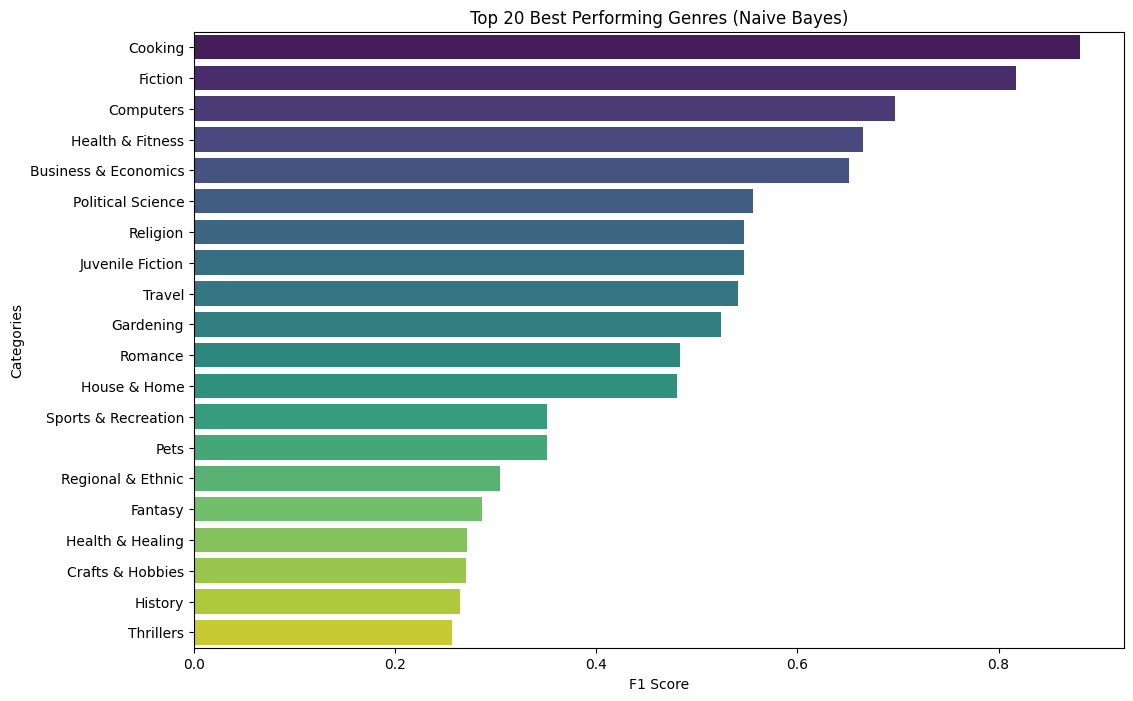

In [ ]:
# Naive Bayes
try:
    if 'tfidf_loaded' in locals() and 'naive_bayes_loaded' in locals():
        # Make predictions and predicted probabilities for validation and test sets
        y_val_nb_pred = naive_bayes_loaded.predict(X_val_tfidf)
        y_test_nb_pred = naive_bayes_loaded.predict(X_test_tfidf)
        y_val_nb_proba = naive_bayes_loaded.predict_proba(X_val_tfidf)
        y_test_nb_proba = naive_bayes_loaded.predict_proba(X_test_tfidf)

        # Produce classification reports for validation and test sets
        val_classification_report_nb = classification_report(y_val, y_val_nb_pred, target_names=mlb.classes_)
        test_classification_report_nb = classification_report(y_test, y_test_nb_pred, target_names=mlb.classes_)

        print("Naive Bayes - Predictions and predicted probabilities")

        # Print predictions and predicted probabilities
        print("Naive Bayes predictions:\n", y_val_nb_pred)
        print("\n\nNaive Bayes predicted probabilities:\n", y_val_nb_proba, "\n")

        print("Naive Bayes - Classification Reports")

        # Print classification reports for validation and test sets
        print("Validation Classification Report:\n", val_classification_report_nb, "\n\n\n\nTest Classification Report:\n", test_classification_report_nb)

        # Calculating F1 scores for each genre to visualise the best performing genres
        f1_scores = f1_score(y_val, y_val_nb_pred, average=None)
        genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

        # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
        top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
        plt.figure(figsize=(12, 8))
        sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
        plt.title('Top 20 Best Performing Genres (Naive Bayes)')
        plt.xlabel('F1 Score')
        plt.ylabel('Categories')
        plt.show()
    else:
        print("Error - Loaded TF-IDF Vectorizer and/or Naive Bayes model not found. Unable to make predictions nor produce classification reports.")
except Exception as e:
    print("Error - Could not make predictions nor produce classification reports with loaded Naive Bayes model. Result: " + str(e) + ".")

### BERT

BERT predictions:
 [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


BERT predicted probabilities:
 [[1.6997529e-04 2.6530237e-04 6.4368558e-04 ... 5.7302467e-03
  6.4620329e-04 2.8021098e-04]
 [8.8880850e-05 9.6102420e-05 2.2693386e-04 ... 2.6834400e-03
  3.8147115e-04 6.7092245e-05]
 [6.8683177e-05 8.0927573e-05 1.8667821e-04 ... 2.3874091e-03
  2.9595711e-04 5.3491327e-05]
 ...
 [5.6058285e-05 1.2148176e-04 2.1152887e-04 ... 2.4822769e-03
  2.5514141e-04 7.7827528e-05]
 [6.9764712e-05 8.0927573e-05 1.9110432e-04 ... 2.3874091e-03
  2.9595711e-04 5.6058285e-05]
 [6.1088547e-05 7.1419017e-05 1.6474655e-04 ... 2.2430879e-03
  2.5514141e-04 4.8325641e-05]]


c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitali

BERT - Classification Report
BERT Classification Report:
                                                            precision    recall  f1-score   support

                                             12th Century       0.00      0.00      0.00         0
                                             15th Century       0.00      0.00      0.00         1
                                             16th Century       0.00      0.00      0.00         1
                                             17th Century       0.00      0.00      0.00         1
                                             18th Century       0.00      0.00      0.00         1
                                             19th Century       0.00      0.00      0.00        35
                                             20th Century       0.00      0.00      0.00        43
                                             21st Century       0.00      0.00      0.00        11
                                                  

c:\Users\elekt\Documents\Project_2026\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elekt\AppData\Local\Temp\ipykernel_13972\2272205038.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')


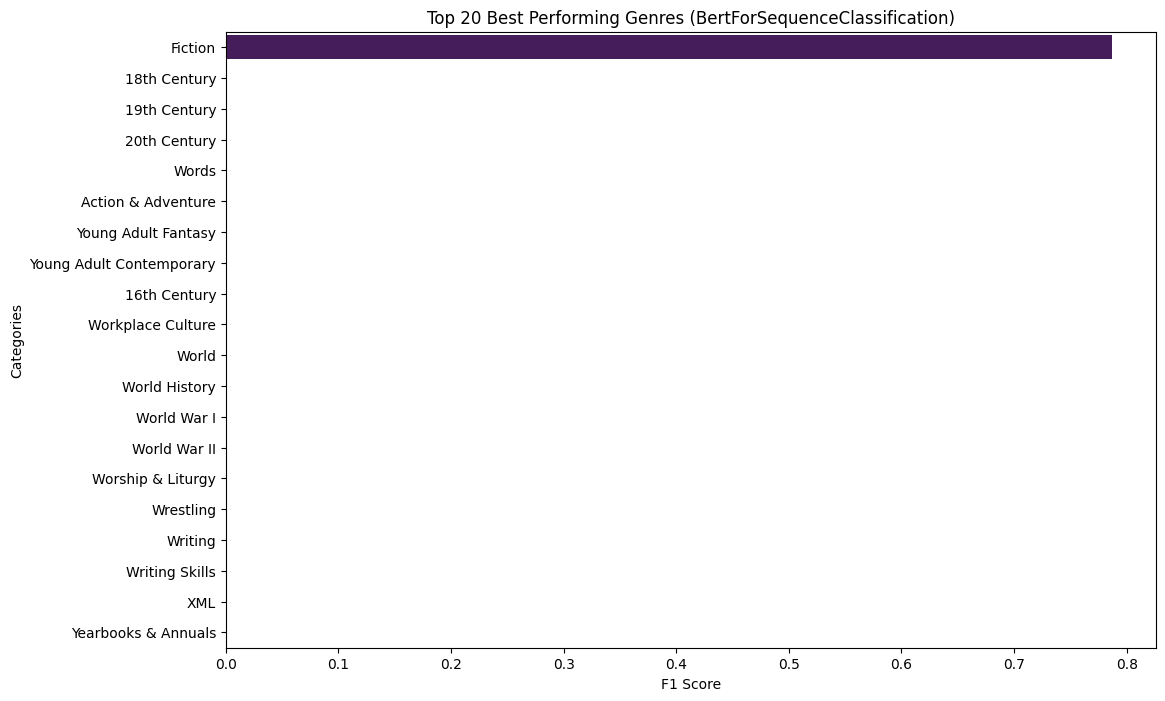

In [ ]:
# BERT
try:
    if 'trainer' in locals() and 'tokenizer_loaded' in locals():
        # Switching BERT to evaluation mode from training mode
        bert_results = trainer.predict(valid_dataset)
        bert_logits = torch.tensor(bert_results.predictions)
        bert_proba = torch.sigmoid(bert_logits).numpy()
        bert_pred = (bert_proba >= 0.5).astype(int)
        print("BERT predictions:\n", bert_pred)
        print("\n\nBERT predicted probabilities:\n", bert_proba)

        # Converting BERT predictions back to genre labels
        # bert_pred_labels = mlb.inverse_transform(bert_pred)
        # print("BERT predicted genres:\n", bert_pred_labels)

        # Produce classification report for BERT predictions
        classification_report_bert = classification_report(y_val, bert_pred, target_names=mlb.classes_)
        print("BERT - Classification Report")
        print("Classification Report:\n", classification_report_bert)
        
        # Calculating F1 scores for each genre to visualise the best performing genres
        f1_scores = f1_score(y_val, bert_pred, average=None)
        genre_f1_scores = pd.DataFrame({'genre': mlb.classes_, 'f1-score': f1_scores})

        # Sort genres by F1 score and show top 20 best performing genres in a horizontal bar chart
        top_20_genres = genre_f1_scores.sort_values(by='f1-score', ascending=False).head(20)
        plt.figure(figsize=(12, 8))
        sns.barplot(data=top_20_genres, x='f1-score', y='genre', palette='viridis')
        plt.title('Top 20 Best Performing Genres (BertForSequenceClassification)')
        plt.xlabel('F1 Score')
        plt.ylabel('Categories')
        plt.show()
    else:
        print("Error - Loaded BERT model and/or tokenizer not found, unable to prepare sample data for predictions.")
except Exception as e:
    print("Error - Could not prepare sample data for BERT predictions. Result: " + str(e) + ".")

## Models Comparison - Machine Learning models and a Deep Learning model

#### We compare the three models by their micro F1 scores, hamming loss, precisions and recalls. We expect the machine learning models to have lower micro F1 scores than BERT. In all models, we expect hamming loss to be at or incredibly close to zero.

C:\Users\elekt\AppData\Local\Temp\ipykernel_13972\1224120590.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, palette='magma')


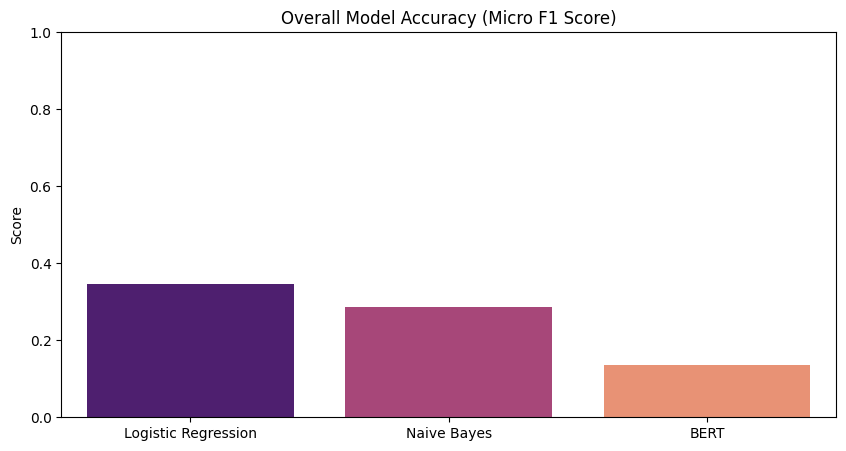

C:\Users\elekt\AppData\Local\Temp\ipykernel_13972\1224120590.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=hamming_losses, palette='magma')


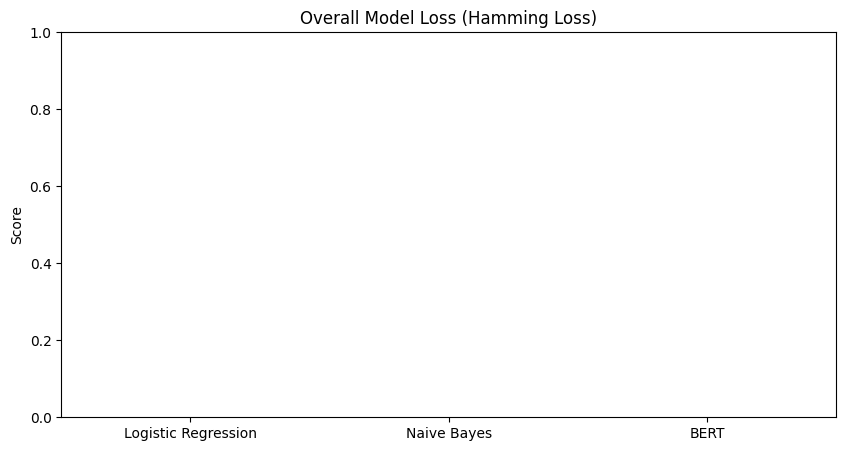

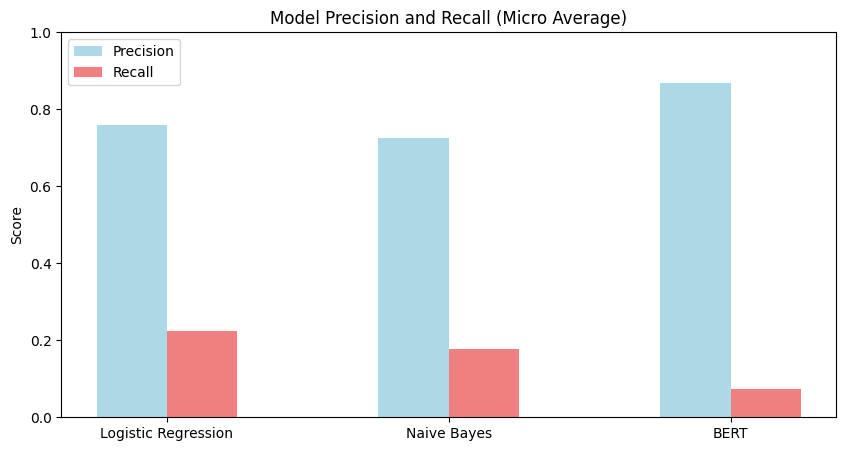

In [ ]:
# data for the model comparison graph
models = ["Logistic Regression", "Naive Bayes", "BERT"]

# F1 scores for the models to compare performance visually
try:
    if 'y_val_lr_pred' in locals() and 'y_val_nb_pred' in locals() and 'bert_pred' in locals():
        f1_scores = [
            f1_score(y_val, y_val_lr_pred, average='micro'),
            f1_score(y_val, y_val_nb_pred, average='micro'),
            f1_score(y_val, bert_pred, average='micro')
        ]
        plt.figure(figsize=(10, 5))
        sns.barplot(x=models, y=f1_scores, palette='magma')
        plt.title('Overall Model Accuracy (Micro F1 Score)')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.show()
    else:
        print("Error - Predictions from one or more models not found. Unable to calculate F1 scores for comparison graph.")
except Exception as e:
    print("Error - Could not calculate F1 scores for the models. Result: " + str(e) + ".")

# Loss score for the models to compare performance visually
try:
    if 'log_reg_pred' in locals() and 'nb_pred' in locals() and 'bert_pred' in locals():
        hamming_losses = [
            hamming_loss(y_val, y_val_lr_pred),
            hamming_loss(y_val, y_val_nb_pred),
            hamming_loss(y_val, bert_pred)
        ]
        plt.figure(figsize=(10, 5))
        sns.barplot(x=models, y=hamming_losses, palette='magma')
        plt.title('Overall Model Loss (Hamming Loss)')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.show()
    else:
        print("Error - Predictions from one or more models not found. Unable to calculate Hamming Loss for comparison graph.")
except Exception as e:
    print("Error - Could not calculate Hamming Loss for the models. Result: " + str(e) + ".")

# Precision and Recall scores for the models to compare performance visually
try:
    if 'log_reg_pred' in locals() and 'nb_pred' in locals() and 'bert_pred' in locals():
        precision_scores = [
            precision_score(y_val, y_val_lr_pred, average='micro'),
            precision_score(y_val, y_val_nb_pred, average='micro'),
            precision_score(y_val, bert_pred, average='micro')
        ]
        recall_scores = [
            recall_score(y_val, y_val_lr_pred, average='micro'),
            recall_score(y_val, y_val_nb_pred, average='micro'),
            recall_score(y_val, bert_pred, average='micro')
        ]
        x = np.arange(len(models))
        width = 0.25
        plt.figure(figsize=(10, 5))
        plt.bar(x - width/2, precision_scores, width=width, label='Precision', color='lightblue')
        plt.bar(x + width/2, recall_scores, width=width, label='Recall', color='lightcoral')
        plt.xticks(x, models)
        plt.title('Model Precision and Recall (Micro Average)')
        plt.ylabel('Score')
        plt.ylim(0, 1)
        plt.legend()
        plt.show()
    else:
        print("Error - Predictions from one or more models not found. Unable to calculate Precision and Recall for comparison graph.")
except Exception as e:
    print("Error - Could not calculate Precision and Recall for the models. Result: " + str(e) + ".")

# report for your best model
# try:
#     if 'bert_pred' in locals():
#         report = classification_report(y_val, bert_pred, target_names=mlb.classes_, output_dict=True)
#         print("Classification Report for BERT model:\n", report)
#     else:
#         print("Error - BERT predictions not found. Unable to produce a classification report.")
# except Exception as e:
#     print("Error - Could not produce a classification report for BERT model. Result: " + str(e) + ".")


## Demo